## Digit Recognition with Support Vector Machine

For this submission, we will use multiclass classifictation with SVMs to train and predict the handwritten digit from the image. 

In [1]:
# Import libraries and modules
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

## Load and prepare data

In [2]:
train_df = pd.read_csv('../input/digit-recognizer/train.csv')
test_df = pd.read_csv('../input/digit-recognizer/test.csv')

In [3]:
# We'll sepearte features and labels now
X = train_df.drop(['label'], axis = 1)
y = train_df['label']

# And now, normalize the features
X = X/255.0
test_df = test_df/255.0

# Converting the data to np.array
X = X.values
test_df = test_df.values

In [4]:
print(X.shape, y.shape)

(42000, 784) (42000,)


In [5]:
# Let's split the available dataset into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 89)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(33600, 784) (8400, 784)
(33600,) (8400,)


Image label:  9


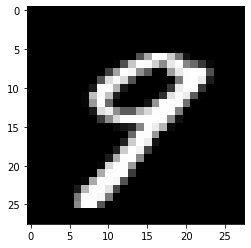

In [6]:
# Let's visualize some samples
def drawImg(sample):
    sample = sample.reshape((28,28))
    plt.imshow(sample, cmap = 'gray')

img = X_train[11]
drawImg(img)
print("Image label: ", y_train[11])

## Multiclass Classification with SVMs

We already know that in the SVM algorithm, we choose the best seperating line/plane for classification. Therefore, it is a binary classifier. But for this dataset, we require the classifier to be able to recognize multiple labels and therefore, we will be taking a look at two techniques for this classification.

### One vs One Classification

In this method, we will choose a number of classifiers where each classifier will perform a binary classification on two of the classes at a time. If we have a total of N classes then we will require  {N choose 2}  classifiers. Then, the class with the majority votes will be identifed as the predicted label.

### One vs Rest Classification

This method will require lesser number of classifiers than before but will take a bit more time. In this method, we take a binary classifier to compare a certain class against rest of the labels. Each classifier will predict if the current label is voted by the majority and then returned back as predicted label. 

The scikit-learn implementation will use this method only.

## Training and making predictions

In [7]:
svm_classif = svm.SVC(kernel = 'linear', C=1.0)

svm_classif.fit(X, y)

SVC(kernel='linear')

In [8]:
## Making final predictions

predictions = svm_classif.predict(test_df)

In [9]:
submission = pd.DataFrame({'ImageId' : range(1,28001), 'Label' : list(predictions)})
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,5
3,4,4
4,5,3


In [10]:
submission.to_csv('submisson.csv', index = False)